<a href="https://colab.research.google.com/github/dipucriodigital/ciencia-de-dados-e-analytics/blob/main/analytics-descriptive-and-predictive/Aula%2001%20-%20Introducao%20Redes%20Neurais.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

In [1]:
# instalando dependências necessárias para o notebook

%pip install -q numpy==2.0.0 scikit-learn==1.6.0 matplotlib==3.9.2 keras==3.13.0 tensorflow==2.20.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 82.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 77.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 107.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.7 MB/s eta 0:00:00


In [2]:
import os
import random
import warnings

# Suprimindo warnings gerados por bibliotecas para uma saída mais limpa
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf

# Suprimindo warnings e mensagens de log do TensorFlow para uma saída mais limpa
tf.get_logger().setLevel('ERROR')

# Definindo uma semente para garantir a reprodutibilidade dos resultados
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Exemplo de um Perceptron

Para este exemplo, vamos criar um dataset que simula a não linearidade da operação XOR. Para isto, criaremos quatro grupos distintos de dados.

In [3]:
# Criando o dataset XOR

from sklearn.preprocessing import StandardScaler  # importa o método Standard Scaler para a normalização (escalamento) dos dados
from sklearn.utils import shuffle    # metodo shuffle vai embaralhar os pontos gerados

nb_samples = 1000              #serão criados 1000 pontos
nsb = int(nb_samples / 4)      #divididos em 4 grupos
X = np.zeros((nb_samples, 2))  #onde aqui definimos o tamanho do conjunto X (pontos) - 1000 pontos com 2 dimensões (coordenadas)
Y = np.zeros((nb_samples, ))   #e do Y (classes conjunto roxo = 1 ou conjunto amarelo = 0)

#vamos definir a pequena variação entre os pontos de cada conjunto
#coordenada 1, -1
X[0:nsb, :] = np.random.multivariate_normal([1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[0:nsb] = 0.0 # classe 0

#coordenada 1, 1
X[nsb:(2 * nsb), :] = np.random.multivariate_normal([1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[nsb:(2 * nsb)] = 1.0 #classe 1

#coordenada -1, 1
X[(2 * nsb):(3 * nsb), :] = np.random.multivariate_normal([-1.0, 1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(2 * nsb):(3 * nsb)] = 0.0 #classe 0

#coordenada -1, -1
X[(3 * nsb):, :] = np.random.multivariate_normal([-1.0, -1.0], np.diag([0.1, 0.1]), size=nsb)
Y[(3 * nsb):] = 1.0 #classe 1

ss = StandardScaler()
X = ss.fit_transform(X) #normaliza os dados para a escala entre 0,1

X, Y = shuffle(X, Y, random_state=SEED) # embaralha os dados

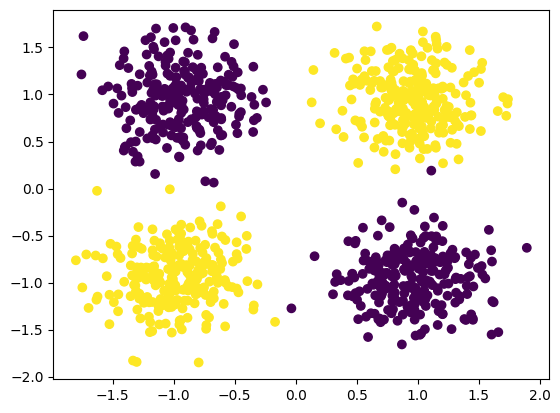

In [4]:
#Exibindo dataset XOR
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=Y)
plt.show()

### Vamos verificar a acurácia usando um perceptron?

In [5]:
from multiprocessing import cpu_count  #cpu_count define quantos núcles tem o computador - para usar paralelismo durante a execução do algoritmo

from sklearn.linear_model import Perceptron  #importa o modelo perceptron
from sklearn.model_selection import cross_val_score #utiliza o método cross validation para indicar a acurácia média do modelo

pc = Perceptron(penalty='l2', alpha=0.1, max_iter=1000, n_jobs=cpu_count(), random_state=SEED) # carrega o perceptron
print(np.mean(cross_val_score(pc, X, Y, cv=10))) # exibe o a acuracia média encontrada pelo modelo

0.514


### Como o perceptron separa as regiões?

In [6]:
#Funções para plotar a superficie (regiões)
#para demonstrar separação pelo modelo criado

import matplotlib.pyplot as plt

def make_meshgrid(x, y, h=.02):
    #define a grade para as coordenadas do gráfico
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    #executa a classificação usando o modelo carregado em clf
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

def plot_model(clf):
    fig, ax = plt.subplots()
    # titulo do gráfico
    title = ('Superfície de Decisão')
    # configura as cooredenadas para plotar o gráfico
    X0, X1 = X[:, 0], X[:, 1]
    xx, yy = make_meshgrid(X0, X1)

    #chama a funcao pra definir os valores do modelo
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_title(title)
    plt.show()

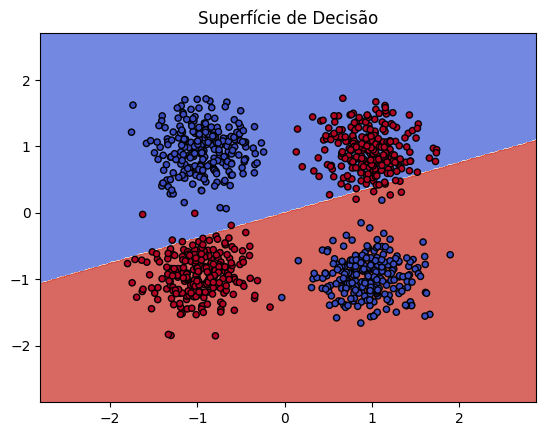

In [7]:
pc.fit(X, Y) # realiza o aprendizado do modelo carregado em pc
plot_model(pc) # as funções acima para executar a classificação e exibir a linha de separaçao dos resultados

## MLP - Multilayer Perceptrons

In [8]:
from keras.models import Sequential
from keras.layers import Dense, Activation

model = Sequential() # carrega um modelo feed-forward

model.add(Dense(4, input_dim=2)) #cria uma camada densa com com 4 neuronios e 2 entradas
model.add(Activation('tanh'))   #usando função de ativação tangente hiperbólica

model.add(Dense(2))  #cria uma camada densa com com 2 neuronios (que recebe as saídas da camada anterior)
model.add(Activation('softmax'))   #usando função de ativação softmax para definir qual é a classe na saída

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']) # define a rede neural

In [ ]:
#vamos separar o conjunto de treinamento e de testes
#30% para testes, o restante para treinamento

from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=SEED) # separa o conjunto de teste com 30% dos dados sorteados aleatóriamente com seed definido
#outros 70% são definidos no conjunto de teste

In [10]:
#treinamento da rede neural 
#usando 100 épocas

#método fit executa o treinamento
model.fit(X_train,  #para o conjunto de teste "train" onde x_train sao os atributos
          to_categorical(Y_train, num_classes=2),  #e y_train sao as classes
          epochs=100,  #em 100 épocas
          batch_size=32, #de 32 em 32
          validation_data=(X_test, to_categorical(Y_test, num_classes=2))) # e demonstrando a acurácia de teste com o conjunto "X_test e Y_test"

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.5043 - loss: 0.7184 - val_accuracy: 0.4933 - val_loss: 0.7106
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4643 - loss: 0.7036 - val_accuracy: 0.4567 - val_loss: 0.6978
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4443 - loss: 0.6910 - val_accuracy: 0.4600 - val_loss: 0.6865
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4700 - loss: 0.6800 - val_accuracy: 0.4900 - val_loss: 0.6763
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4914 - loss: 0.6699 - val_accuracy: 0.5200 - val_loss: 0.6667
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5514 - loss: 0.6603 - val_accuracy: 0.5933 - val_loss: 0.6574
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6471 - loss: 0.6510 - val_accuracy: 0.7067 - val_loss: 0.6482
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7386 - loss: 0.6418 - val_accuracy: 0.7700 - 

In [11]:
#verificação(predição) usando a base de teste
#qual seria a resposta da rede treinada se ela classificar os pontos que estao no conjunto de testes?

Y_eval_mlp = np.argmax(model.predict(X_test), axis=1) #retorna as classes definidas pelo modelo

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


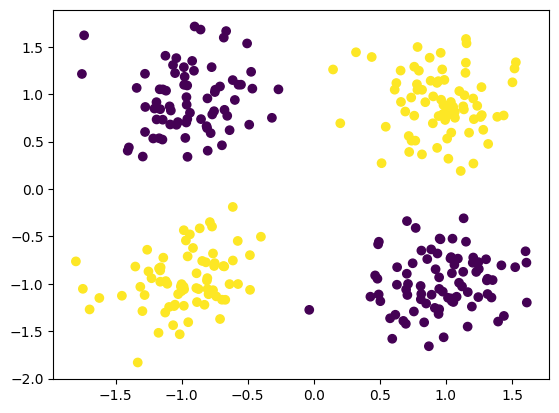

In [12]:
#plotando os resultados
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

### Superficie usando o modelo atual com tanh

In [13]:
#para verificarmos os limites entre os conjuntos de classificação
#vamos criar um conjunto com muitos pontos gerados aleatóriamente
#e usar o modelo para definir qual seria sua classe

Xm = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada X
Ym = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada Y
Xmg, Ymg = np.meshgrid(Xm, Ym)  #retorna as coordenadas da grade 2-D com base nas coordenadas contidas nos vetores x e y
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T #cria o conjunto de entradas para as coordenadas geradas

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1) # usa o modelo carregado em model para realizar a classificação

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 43s 1ms/step


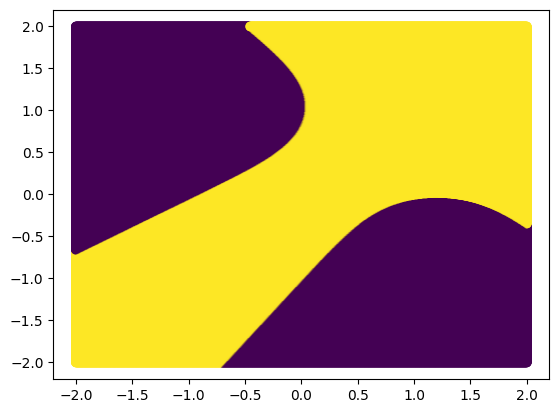

In [14]:
#plotando os resultados
import matplotlib.pyplot as plt
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

### E se criarmos um modelo usando função de ativação Relu?

In [15]:
#para isto, vamos reproduzir a mesma rede neural anterior
#mas mudando a função de ativação

model = Sequential() # carrega um modelo feed-forward

model.add(Dense(4, input_dim=2)) #cria uma camada densa com com 4 neuronios e 2 entradas
model.add(Activation('relu'))   #usando função de ativação relu

model.add(Dense(2))  #cria uma camada densa com com 2 neuronios (que recebe as saídas da camada anterior)
model.add(Activation('softmax'))   #usando função de ativação softmax para definir qual é a classe na saída

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy']) # define a rede neural

In [ ]:
#vamos separar o conjunto de treinamento e de testes
#30% para testes, o restante para treinamento

from keras.utils import to_categorical
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=SEED) # separa o conjunto de teste com 30% dos dados sorteados aleatóriamente com seed definido 
#outros 70% são definidos no conjunto de teste

#treinamento da rede neural 
#usando 100 épocas

#método fit executa o treinamento
model.fit(X_train,  #para o conjunto de teste "train" onde x_train sao os atributos
          to_categorical(Y_train, num_classes=2),  #e y_train sao as classes
          epochs=100,  #em 100 épocas
          batch_size=32, #de 32 em 32
          validation_data=(X_test, to_categorical(Y_test, num_classes=2))) # e demonstrando a acurácia de teste com o conjunto "X_test e Y_test"          

Epoch 1/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4114 - loss: 0.7076 - val_accuracy: 0.4300 - val_loss: 0.6907
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4200 - loss: 0.6950 - val_accuracy: 0.4467 - val_loss: 0.6795
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4400 - loss: 0.6833 - val_accuracy: 0.4900 - val_loss: 0.6687
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5529 - loss: 0.6720 - val_accuracy: 0.6533 - val_loss: 0.6579
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6657 - loss: 0.6609 - val_accuracy: 0.7000 - val_loss: 0.6469
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6843 - loss: 0.6495 - val_accuracy: 0.7100 - val_loss: 0.6356
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6857 - loss: 0.6377 - val_accuracy: 0.7100 - val_loss: 0.6238
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6929 - loss: 0.6256 - val_accuracy: 0.7100 - 

In [17]:
#verificação(predição) usando a base de teste
#qual seria a resposta da rede treinada se ela classificar os pontos que estao no conjunto de testes?

Y_eval_mlp = np.argmax(model.predict(X_test), axis=1) #retorna as classes definidas pelo modelo

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


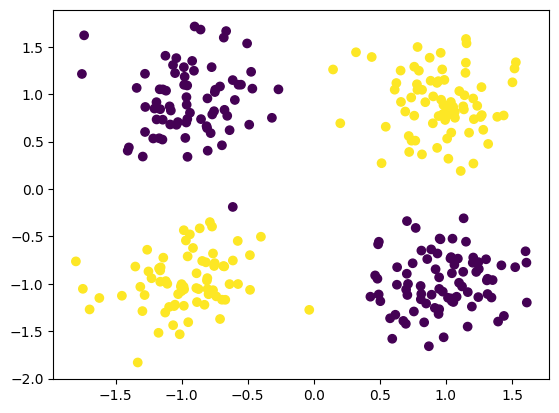

In [18]:
#plotando os resultados
import matplotlib.pyplot as plt
plt.scatter(X_test[:, 0], X_test[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico

In [19]:
#para verificarmos os limites entre os conjuntos de classificação
#vamos criar um conjunto com muitos pontos gerados aleatóriamente
#e usar o modelo para definir qual seria sua classe

Xm = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada X
Ym = np.linspace(-2.0, 2.0, 1000) # cria 1000 pontos para a coordenada Y
Xmg, Ymg = np.meshgrid(Xm, Ym)  #retorna as coordenadas da grade 2-D com base nas coordenadas contidas nos vetores x e y
X_eval = np.vstack([Xmg.ravel(), Ymg.ravel()]).T #cria o conjunto de entradas para as coordenadas geradas

Y_eval_mlp = np.argmax(model.predict(X_eval), axis=1) # usa o modelo carregado em model para realizar a classificação

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 44s 1ms/step


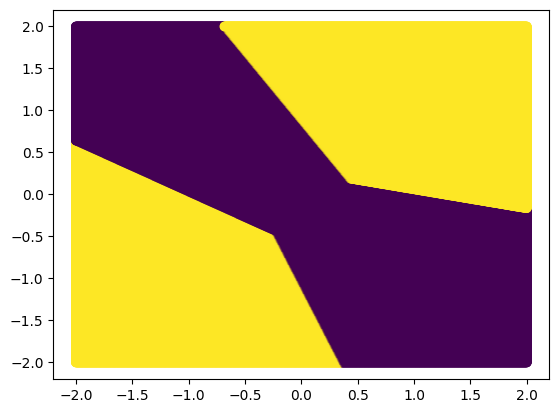

In [20]:
#plotando os resultados
import matplotlib.pyplot as plt
plt.scatter(X_eval[:, 0], X_eval[:, 1], c=Y_eval_mlp) # exibe pontos para coordenadas em X_Test definindo as cores a partir dos dados em Y_eval_mlp
plt.show() #exibe gráfico